In [1]:
import os
import copy
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
import torch

import util
import peripheral

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

In [2]:
"""
Typical configuration for a normal hearing auditory nerve model.

The `config_random_slice` section has been commented out. This section
is relevant for fixed-length stimuli where the final nervegram should
be excerpted from a longer nervegram with some temporal jitter.
"""
config_peripheral_model = {
    "config_anf_rate_level": {
        "compression_power": 0.3,
        "compression_power_default": 0.3,
        "dynamic_range": [
            20.0,
            40.0,
            80.0
        ],
        "dynamic_range_interval": 0.95,
        "envelope_mode": True,
        "rate_max": [
            250.0,
            250.0,
            100.0
        ],
        "rate_spont": [
            70.0,
            4.0,
            0.1
        ],
        "threshold": [
            0.0,
            12.0,
            28.0
        ]
    },
    "config_anf_spike_generator": {
        "mode": "approx",
        "n_per_channel": [
            384,
            160,
            96
        ]
    },
    "config_cochlear_filterbank": {
        "bw_mult": 1.0,
        "cfs": {
            "num": 50,
            "start": 60.0,
            "stop": 16000.0
        },
        "fir_dur": 0.05,
        "order": 4,
        "type": "gammatone_filterbank_fir"
    },
    "config_ihc_lowpass_filter": {
        "cutoff": 3000,
        "fir_dur": 0.05,
        "order": 7
    },
    "config_ihc_transduction": {
        "rectify": True
    },
    "config_middle_ear_filter": {
        "minimum_phase": True,
        "mode": "iso226_2003",
        "numtaps": 1025
    },
    "config_random_slice": {
        # "buffer": [
        #     0,
        #     500
        # ],
        # "size": [
        #     50,
        #     20000
        # ]
    },
    "sr_input": 50000.0,
    "sr_output": 10000.0
}


In [3]:
"""
Construct the PyTorch model and assign it to the available device.
"""
model = peripheral.Model(**config_peripheral_model)
model.to(device)


Model(
  (body): Sequential(
    (middle_ear_filter): MiddleEarFilter()
    (cochlear_filterbank): GammatoneFilterbank()
    (ihc_transduction): IHCTransduction()
    (ihc_lowpass_filter): IHCLowpassFilter()
    (anf_rate_level): SigmoidRateLevelFunction(
      (envelope_function): HilbertEnvelope(
        (hilbert): Hilbert()
      )
    )
    (anf_spike_generator): BinomialSpikeGenerator()
  )
  (head): Identity()
)

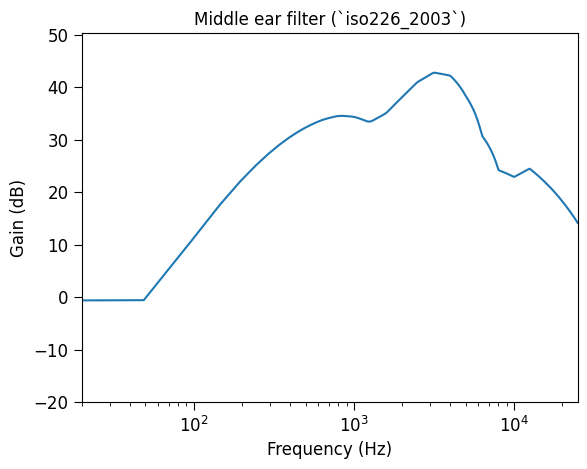

In [4]:
"""
Visualize the middle ear filter's frequency response.
"""
sr = model.sr_input
fir = model.body.middle_ear_filter.fir.detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = util.periodogram(fir, sr)
ax.plot(fxx, pxx)
util.format_axes(
    ax,
    xscale="log",
    xlimits=[20, sr / 2],
    ylimits=[-20, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Gain (dB)",
    str_title="Middle ear filter (`iso226_2003`)",
)
plt.show()


/rdma/vast-rdma/vast/mcdermott/msaddler/peripheral_model/util.py:171: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


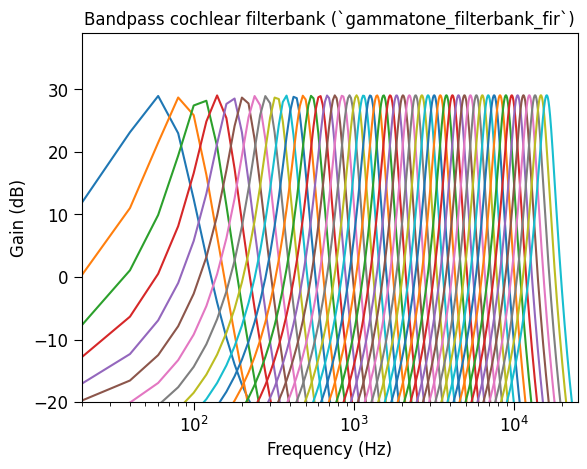

In [5]:
"""
Visualize the cochlear filterbank's frequency response.
"""
sr = model.sr_input
fir = model.body.cochlear_filterbank.fir.detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = util.periodogram(fir, sr)
ax.plot(fxx, pxx.T)
util.format_axes(
    ax,
    xscale="log",
    xlimits=[20, sr / 2],
    ylimits=[-20, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Gain (dB)",
    str_title="Bandpass cochlear filterbank (`gammatone_filterbank_fir`)",
)
plt.show()


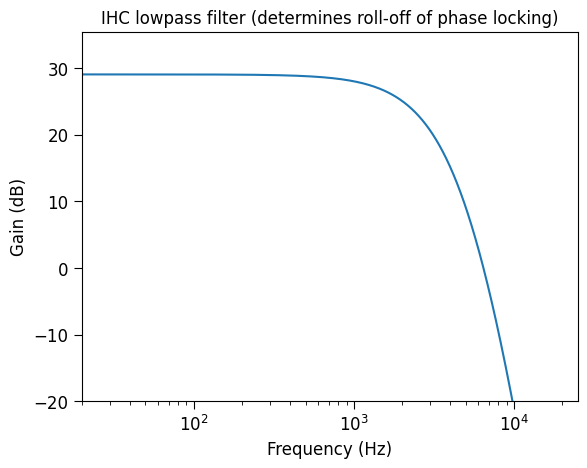

In [6]:
"""
Visualize the IHC lowpass filter's frequency response.
"""
sr = model.sr_input
fir = model.body.ihc_lowpass_filter.fir.detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = util.periodogram(fir, sr)
ax.plot(fxx, pxx)
util.format_axes(
    ax,
    xscale="log",
    xlimits=[20, sr / 2],
    ylimits=[-20, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Gain (dB)",
    str_title="IHC lowpass filter (determines roll-off of phase locking)",
)
plt.show()


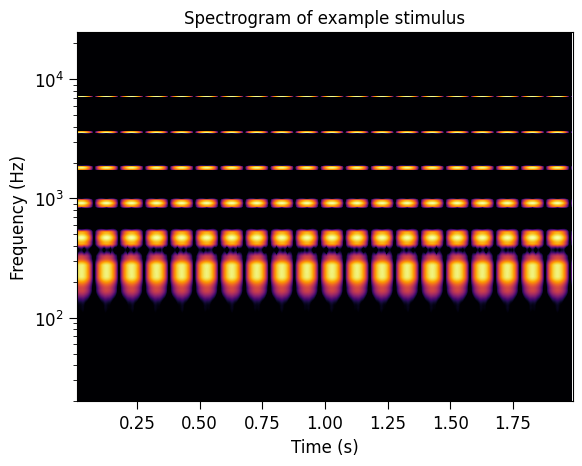

In [7]:
"""
Generate an example stimulus.
"""
sr = model.sr_input

t = np.arange(0, 2, 1 / sr)
x = np.zeros_like(t)
f0 = 220
for h in [1, 2, 4, 8, 16, 32]:
    f = h * f0
    x += np.sin(2 * np.pi * f * t)
x *= (1 + np.sin(2 * np.pi * 10 * t))
x = util.set_dbspl(x, 75.0)

ipd.display(ipd.Audio(rate=sr, data=x))

fig, ax = plt.subplots()
nfft = 1024
kwargs_specgram = {
    "NFFT": nfft,
    "Fs": sr,
    "mode": "magnitude",
    "scale": "dB",
    "cmap": "inferno",
    "noverlap": int(0.9 * nfft),
    "clim": [-60, None],
}
ax.specgram(x, **kwargs_specgram)
ax = util.format_axes(
    ax,
    yscale="log",
    ylimits=[20, sr / 2],
    str_xlabel="Time (s)",
    str_ylabel="Frequency (Hz)",
    str_title="Spectrogram of example stimulus",
)
plt.show()


In [8]:
"""
Run the model on the example stimulus (a tensor with a batch axis).
"""
x_tensor = torch.as_tensor(x[None], dtype=torch.float32, device=device)
print(f"{x_tensor.shape=}")

nervegram = model(x_tensor)
print(f"{nervegram.shape=}")


x_tensor.shape=torch.Size([1, 100000])
nervegram.shape=torch.Size([1, 3, 50, 20000])


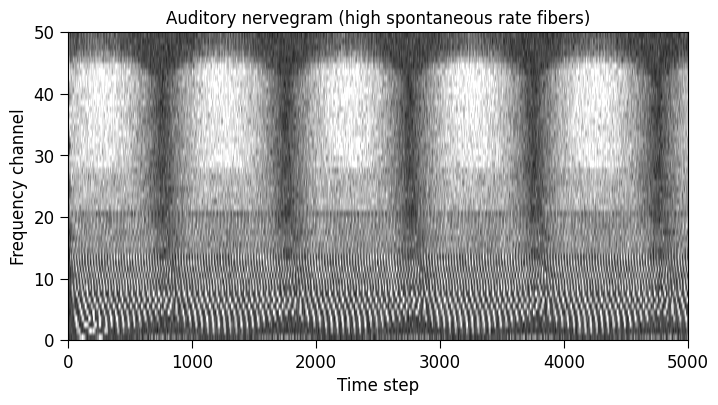

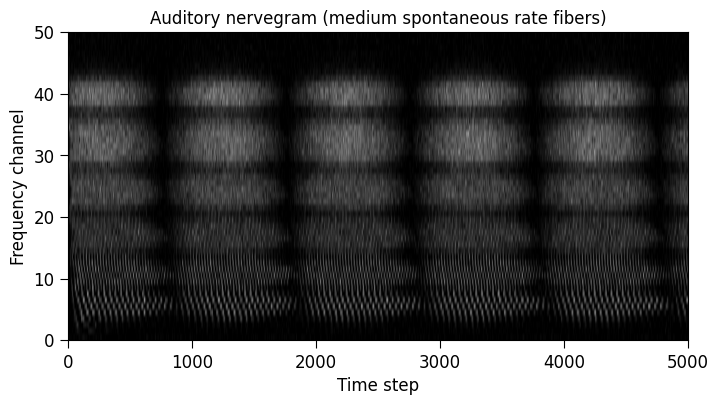

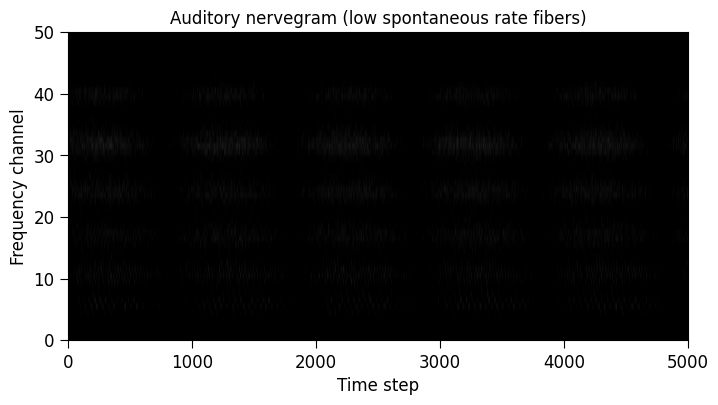

In [9]:
"""
Visualize an excerpt of the nervegram.
"""
for itr, label in enumerate(["high", "medium", "low"]):
    img = nervegram[0, itr, :, :5000].detach().cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(
        img,
        origin="lower",
        aspect="auto",
        extent=[0, img.shape[1], 0, img.shape[0]],
        cmap="gray",
        vmin=0,
        vmax=10,
    )
    ax = util.format_axes(
        ax,
        str_xlabel="Time step",
        str_ylabel="Frequency channel",
        str_title=f"Auditory nervegram ({label} spontaneous rate fibers)",
    )
    plt.show()


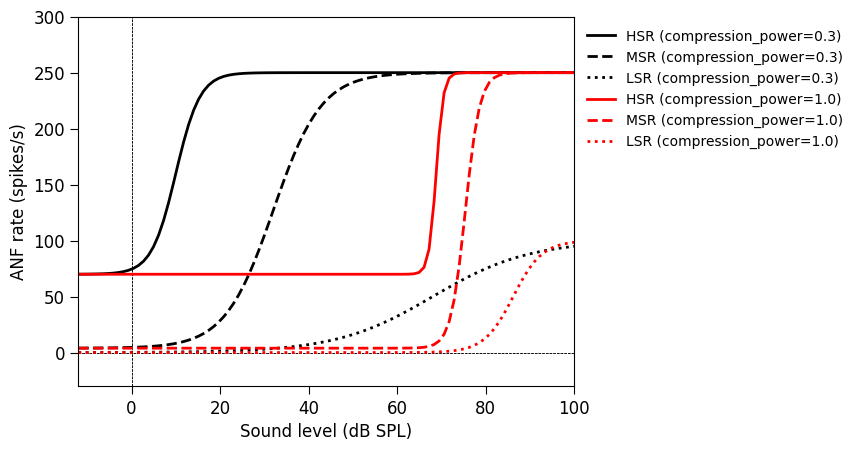

In [10]:
"""
Visualize the auditory nerve fiber rate-level functions.
These functions can be altered to simulate peripheral
effects of hearing loss. One convenient way to alter
them is with the `compression_power` parameter, which
can be used to simulate outer hair cell loss:
- compression_power=0.3 (normal hearing)
- compression_power=1.0 (no compressive nonlinearity)
"""
level_db = np.linspace(-12, 100, 100)
level = 20e-6 * np.power(10, level_db / 20)
fig, ax = plt.subplots()
list_color = ["k", "r"]
list_compression_power = [0.3, 1.0]
for itr, (compression_power, color) in enumerate(zip(list_compression_power, list_color)):
    layer = peripheral.SigmoidRateLevelFunction(
        rate_spont=[70.0, 4.0, 0.1],
        rate_max=[250.0, 250.0, 100.0],
        threshold=[0.0, 12.0, 28.0],
        dynamic_range=[20.0, 40.0, 80.0],
        dynamic_range_interval=0.95,
        compression_power=compression_power,
        compression_power_default=0.3,
        envelope_mode=False,
        dtype=torch.float32,
    )
    rate = layer(torch.tensor(level[None, None, :], dtype=torch.float32))
    rate = torch.squeeze(rate).numpy()
    kwargs_plot = {"color": color, "lw": 2}
    ax.axvline(0, color="k", lw=0.5, ls="--")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    for itr_spont in range(rate.shape[0]):
        label = ["HSR", "MSR", "LSR"][itr_spont]
        label = f"{label} ({compression_power=:.1f})"
        ax.plot(
            level_db,
            rate[itr_spont],
            **kwargs_plot,
            ls=["-", "--", ":"][itr_spont],
            label=label,
        )
ax.legend(
    loc="upper left",
    bbox_to_anchor=[1, 1],
    frameon=False,
)
ax = util.format_axes(
    ax,
    xlimits=[level_db[0], level_db[-1]],
    ylimits=[-30, 300],
    str_xlabel="Sound level (dB SPL)",
    str_ylabel="ANF rate (spikes/s)",
)
plt.show()


In [11]:
"""
Helper class I put together to help map audiogram thresholds to
compression powers. I also linearly scale the cochlear filter
bandwidths to widen proportionally with the loss of compression. 
"""

class PeripheralModelFitter:
    def __init__(
        self,
        compression_power_fp=np.linspace(0.3, 1.0, 100),
        compression_power_default=0.3,
        threshold=0.0,
        dynamic_range=20.0,
        dynamic_range_interval=0.95,
        scale_bw=True,
    ):
        """ """
        self.compression_power_fp = compression_power_fp
        self.compression_power_default = compression_power_default
        self.threshold = threshold
        self.dynamic_range = dynamic_range
        self.dynamic_range_interval = dynamic_range_interval
        self.threshold_xp = [
            self.compression_power_to_threshold_estimate(_)
            for _ in self.compression_power_fp
        ]
        self.scale_bw = scale_bw

    def compression_power_to_threshold_estimate(self, compression_power):
        """
        Estimate audiogram threshold for a given compression_power and
        set of model auditory nerve rate-level function parameters.
        """
        shift = 20 * np.log10(20e-6 ** (self.compression_power_default - 1))
        threshold = np.array(self.threshold) * self.compression_power_default + shift
        dynamic_range = np.array(self.dynamic_range) * self.compression_power_default
        y_threshold = (1 - self.dynamic_range_interval) / 2
        k = np.log((1 / y_threshold) - 1) / (dynamic_range / 2)
        x0 = threshold - (np.log((1 / y_threshold) - 1) / (-k))
        x_threshold = np.arange(-30, 120, 0.1)
        x = 20e-6 * np.power(10, x_threshold / 20)
        x = x**compression_power
        x = 20 * np.log10(x / 20e-6)
        y = 1.0 / (1.0 + np.exp(-k * (x - x0)))
        x_threshold = x_threshold[y >= y_threshold][0]
        return x_threshold

    def audiogram_to_compression_power(self, freq, dbhl, cfs):
        """
        Map audiogram frequencies and levels to compression powers
        (at each CF) that will yield a similar model audiogram.
        """
        audiogram_compression_power = np.interp(
            x=dbhl,
            xp=self.threshold_xp,
            fp=self.compression_power_fp,
        )
        compression_power = np.interp(
            x=cfs,
            xp=freq,
            fp=audiogram_compression_power,
        )
        return compression_power

    def compression_power_to_bw_mult(self, compression_power):
        """
        Linearly interpolate `bw_mult` between 1 and 3 for each CF.
        """
        bw_mult = np.interp(
            x=compression_power,
            xp=[self.compression_power_default, 1.0],
            fp=[1.0, 3.0],
        )
        return bw_mult


fitter = PeripheralModelFitter()


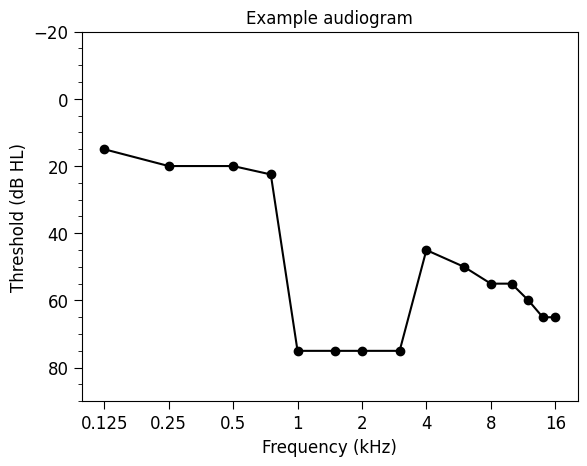

In [12]:
"""
Example audiogram to fit (atypical audiogram used to show larger effect).
"""
freq = np.array([125, 250, 500, 750,1000, 1500, 2000, 3000, 4000, 6000, 8000, 10000, 12000, 14000,16000])
# dbhl = np.array([15, 20, 20, 22.5, 25, 30, 35, 40, 45, 50, 55, 55, 60, 65, 65])
dbhl = np.array([15, 20, 20, 22.5, 75, 75, 75, 75, 45, 50, 55, 55, 60, 65, 65])

fig, ax = plt.subplots()
ax.plot(freq, dbhl, "ko-")
ax = util.format_axes(
    ax,
    xscale="log",
    xticks=[125, 250, 500, 1000, 2000, 4000, 8000, 16000],
    xticklabels=[0.125, 0.25, 0.5, 1, 2, 4, 8, 16],
    xticks_minor=[],
    ylimits=[90, -20],
    yticks=np.arange(80, -21, -20),
    yticks_minor=np.arange(90, -21, -5),
    str_xlabel="Frequency (kHz)",
    str_ylabel="Threshold (dB HL)",
    str_title="Example audiogram",
)
plt.show()


In [13]:
"""
Use the `fitter` object to compute appropriate `compression_power` and `bw_mult`
for each auditory nerve model frequency channel. These parameters are then put
in a new config dict (`config_peripheral_model_impaired`).
"""
cfs = util.erbspace(**config_peripheral_model["config_cochlear_filterbank"]["cfs"])
compression_power = fitter.audiogram_to_compression_power(freq, dbhl, cfs)
bw_mult = fitter.compression_power_to_bw_mult(compression_power)

config_peripheral_model_impaired = copy.deepcopy(config_peripheral_model)
config_peripheral_model_impaired["config_anf_rate_level"]["compression_power"] = compression_power
config_peripheral_model_impaired["config_cochlear_filterbank"]["bw_mult"] = bw_mult
config_peripheral_model_impaired


{'config_anf_rate_level': {'compression_power': array([0.35656566, 0.35656566, 0.35656566, 0.35962939, 0.36577235,
         0.37244172, 0.37968261, 0.38080808, 0.38080808, 0.38080808,
         0.38080808, 0.38080808, 0.38324545, 0.38677364, 0.39060417,
         0.42456403, 0.63046572, 0.85401169, 1.        , 1.        ,
         1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 1.        , 1.        , 1.        ,
         0.92592807, 0.80187193, 0.66718507, 0.57875307, 0.59111079,
         0.60452747, 0.61909387, 0.6349085 , 0.65470539, 0.67769173,
         0.70264784, 0.72247475, 0.72247475, 0.72247475, 0.75040817,
         0.79902665, 0.86047755, 0.93859573, 0.97171717, 0.97171717]),
  'compression_power_default': 0.3,
  'dynamic_range': [20.0, 40.0, 80.0],
  'dynamic_range_interval': 0.95,
  'envelope_mode': True,
  'rate_max': [250.0, 250.0, 100.0],
  'rate_spont': [70.0, 4.0, 0.1],
  'threshold': [0.0, 12.0, 28.0]},
 'config_anf_spike_gen

In [14]:
"""
Construct the impaired model using `config_peripheral_model_impaired`
"""
model_impaired = peripheral.Model(**config_peripheral_model_impaired)
model_impaired.to(device)


Model(
  (body): Sequential(
    (middle_ear_filter): MiddleEarFilter()
    (cochlear_filterbank): GammatoneFilterbank()
    (ihc_transduction): IHCTransduction()
    (ihc_lowpass_filter): IHCLowpassFilter()
    (anf_rate_level): SigmoidRateLevelFunction(
      (envelope_function): HilbertEnvelope(
        (hilbert): Hilbert()
      )
    )
    (anf_spike_generator): BinomialSpikeGenerator()
  )
  (head): Identity()
)

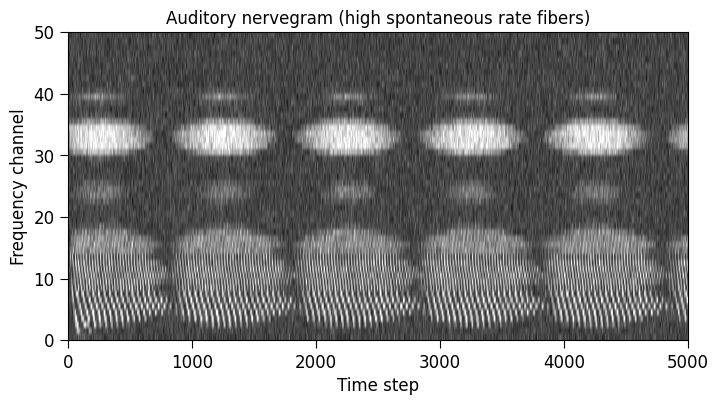

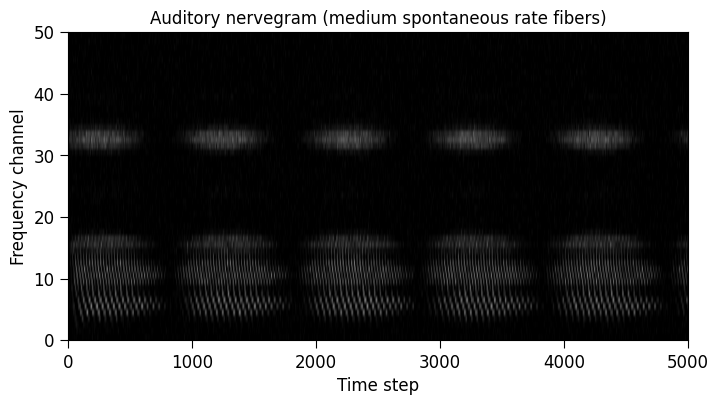

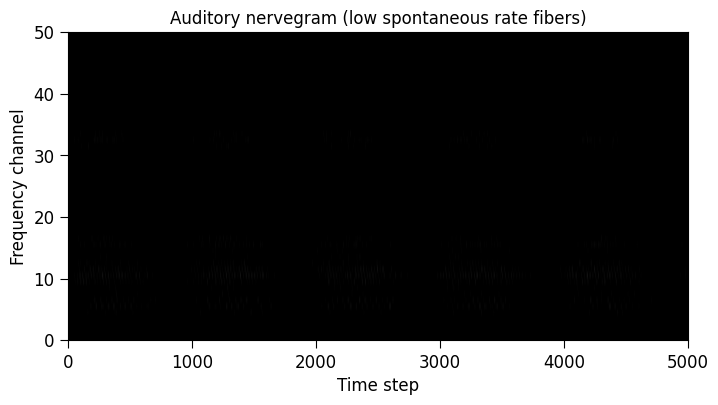

In [15]:
"""
Run the model on an example stimulus and visualize the outputs.
NOTE: less extreme hearing losses are not always easily visible
in in these color maps (try time-averaged excitation patterns).
"""
nervegram_impaired = model_impaired(x_tensor)

for itr, label in enumerate(["high", "medium", "low"]):
    img = nervegram_impaired[0, itr, :, :5000].detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(
        img,
        origin="lower",
        aspect="auto",
        extent=[0, img.shape[1], 0, img.shape[0]],
        cmap="gray",
        vmin=0,
        vmax=10,
    )
    ax = util.format_axes(
        ax,
        str_xlabel="Time step",
        str_ylabel="Frequency channel",
        str_title=f"Auditory nervegram ({label} spontaneous rate fibers)",
    )
    plt.show()
